# Strong Scaling

This third experiment focus on the strong scaling.\
We fix $N$, vary $P$. Sample sort has $O(NlogN/P)$ local work and $O(N)$ aggregate communication; communication will dominate eventually. Find the cross-over for your machine.

The experiment focus mostly on **MPI** level (since **k** literally is the number of MPI ranks). The number of **OMP threads** are fixed to 4. The number of **MPI ranks** increase exponentially from **4** to **64**.

* **n_bits** : $64$
* **n_keys** : $10^9$
* **n_threads** : $4$
* **keys_distribution** : uniform
* **sorting_strategy** : radix
* **merging_strategy** : bin

Experiments were executed on [**Orfeo, partition GENOA**](https://orfeo-doc.areasciencepark.it/HPC/computational-resources/).

The key metrics here are **time_comunication_seconds** and **total_seconds**.

In [26]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [27]:
results = pd.read_csv("../Parallel/results/strong_scaling.csv")
results = results[
    ["n_bits", "n_key", "n_ranks", "n_threads", "time_communication_seconds", "time_total_seconds"]
]
results.head()

,n_bits,n_key,n_ranks,n_threads,time_communication_seconds,time_total_seconds
0,32,1000000000,4,4,0.745107,22.174061
1,32,1000000000,8,4,0.573162,12.183081
2,32,1000000000,16,4,0.236523,7.243934
3,32,1000000000,32,4,0.209851,5.224494
4,32,1000000000,64,4,0.213323,3.103495


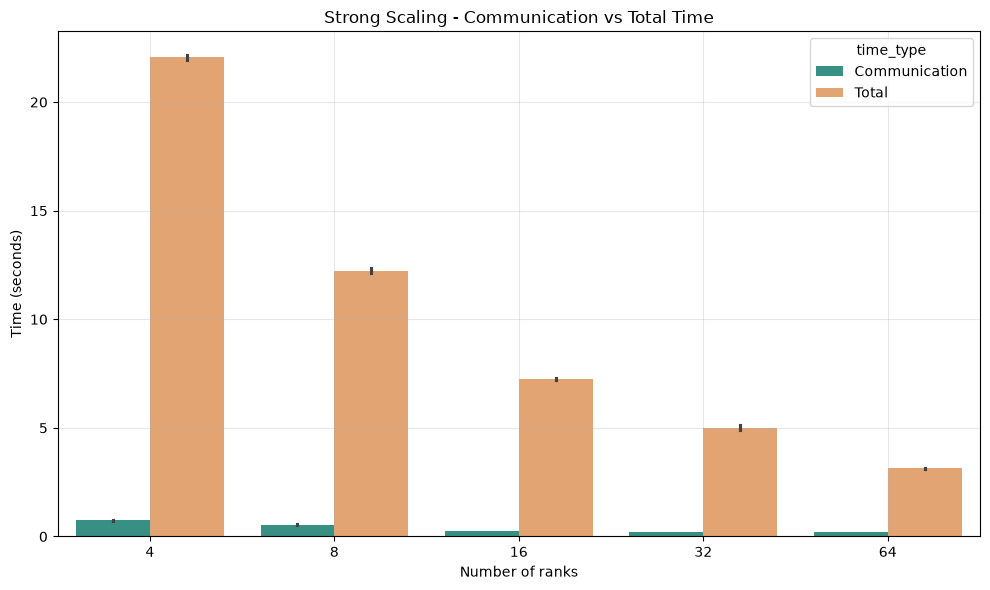

In [28]:
plot_data = results.melt(
    id_vars=["n_bits", "n_key", "n_ranks", "n_threads"],
    value_vars=[
        "time_communication_seconds",
        "time_total_seconds"
    ],
    var_name="time_type",
    value_name="time_seconds"
)

plot_data["time_type"] = plot_data["time_type"].map({
    "time_communication_seconds": "Communication",
    "time_total_seconds": "Total"
})

custom_palette = {
    "Communication" : "#2A9D8F",
    "Total" : "#F4A261"
}

plt.figure(figsize=(10, 6))

sns.barplot(
    data=plot_data,
    x="n_ranks",
    y="time_seconds",
    hue="time_type",
    palette=custom_palette
)

plt.xlabel("Number of ranks")
plt.ylabel("Time (seconds)")
plt.title("Strong Scaling - Communication vs Total Time")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

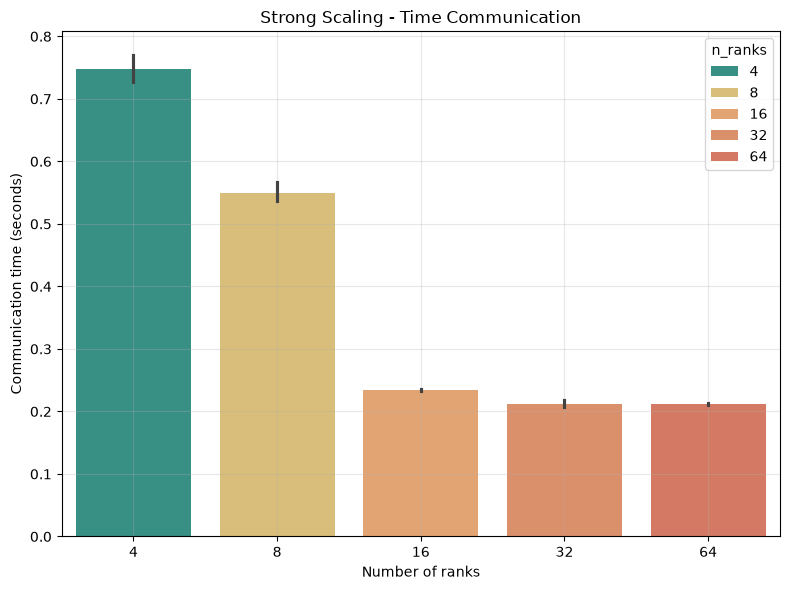

In [29]:
custom_palette = {
    1 :"#264653",
    2 : "#287271",
    4 : "#2a9d8f",
    8 : "#e9c46a",
    16 : "#f4a261",
    32 : "#ee8959",
    64 : "#e76f51"
}

plt.figure(figsize=(8, 6))

sns.barplot(
    data=results,
    x="n_ranks",
    y="time_communication_seconds",
    hue="n_ranks",
    palette=custom_palette
)

plt.xlabel("Number of ranks")
plt.ylabel("Communication time (seconds)")
plt.title("Strong Scaling - Time Communication")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

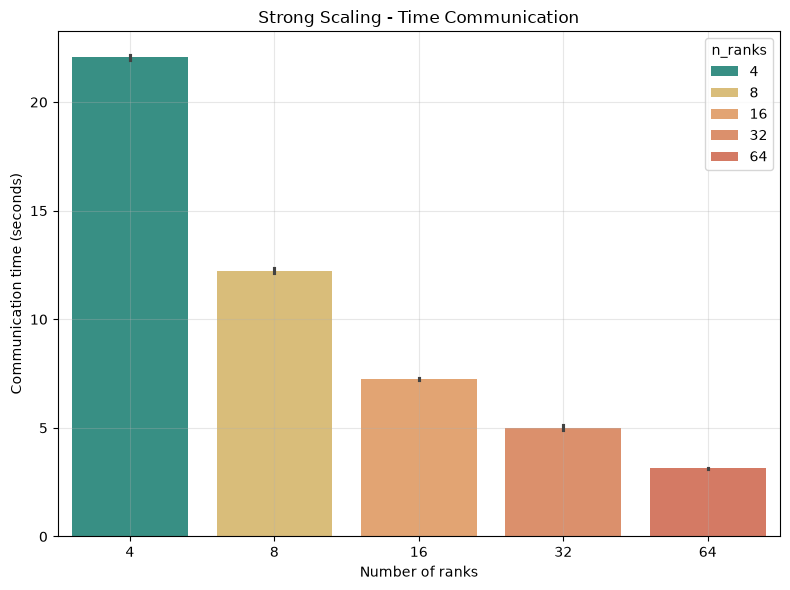

In [30]:
custom_palette = {
    1 :"#264653",
    2 : "#287271",
    4 : "#2a9d8f",
    8 : "#e9c46a",
    16 : "#f4a261",
    32 : "#ee8959",
    64 : "#e76f51"
}

plt.figure(figsize=(8, 6))

sns.barplot(
    data=results,
    x="n_ranks",
    y="time_total_seconds",
    hue="n_ranks",
    palette=custom_palette
)

plt.xlabel("Number of ranks")
plt.ylabel("Communication time (seconds)")
plt.title("Strong Scaling - Time Communication")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()